In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
fp = '../data/raw/WATER LEVEL HUASCO-1.csv'
df = pd.read_csv(fp)

In [24]:
columns_to_keep = ['BHID', 'DATE', 'WATER_LEVEL']
condition = df['BHID'].str.startswith('HPS-', na=False)
filtered_df = df[condition]
final_df = filtered_df[columns_to_keep]

In [25]:
final_df

,BHID,DATE,WATER_LEVEL
238,HPS-01,2002-12-06,0.77
239,HPS-02,2002-12-06,0.77
240,HPS-03,2002-12-06,0.03
241,HPS-04,2002-12-06,3.30
242,HPS-06,2002-12-06,3.23
...,...,...,...
7474,HPS-11,02-12-2016,0.64
7475,HPS-12,02-12-2016,0.93
7476,HPS-36,02-12-2016,0.00
7477,HPS-37,02-12-2016,0.02


In [32]:
def plot_borehole_water_level(dataframe, borehole_id):
    """
    Filters the dataframe for a specific borehole and plots its water level over time.
    """
    # FILTER THE DATAFRAME TO KEEP ONLY THE SELECTED BOREHOLE
    # UPPERCASE COMMENT: CHOSEN BOREHOLE DATA EXTRACTION
    site_data = dataframe[dataframe['BHID'] == borehole_id].copy()
    
    # ENSURE THE DATE COLUMN IS IN DATETIME FORMAT FOR PROPER PLOTTING
    # UPPERCASE COMMENT: TEMPORAL DATA CONVERSION TO AVOID X-AXIS OVERLAP
    site_data['DATE'] = pd.to_datetime(site_data['DATE'], format='mixed', dayfirst=True)
    
    # SORT BY DATE TO ENSURE THE LINE PLOTS IN THE CORRECT CHRONOLOGICAL ORDER
    site_data = site_data.sort_values('DATE')
    
    # CHECK IF THE FILTERED DATAFRAME HAS VALID DATA TO PLOT
    if site_data.empty:
        print(f"No data found for borehole: {borehole_id}")
        return
        
    # SET THE VISUAL THEME USING SEABORN
    sns.set_theme(style="whitegrid")
    
    # INITIALIZE THE FIGURATIVE SPACE
    plt.figure(figsize=(10, 5))
    
    # CREATE THE LINE PLOT FOR WATER LEVEL OVER TIME
    # WE ADD MARKERS TO SEE INDIVIDUAL MEASUREMENT POINTS CLEARLY
    sns.lineplot(
        data=site_data, 
        x='DATE', 
        y='WATER_LEVEL', 
        marker='o', 
        color='steelblue',
        linewidth=2
    )
    
    # STYLE THE PLOT WITH DESCRIPTIVE LABELS AND TITLE
    plt.title(f'Water Level Trend over Time - Borehole {borehole_id}', fontsize=14, pad=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Water Level (m)', fontsize=12)
    plt.gca().invert_yaxis()
    
    # ROTATE X-AXIS LABELS TO PREVENT TEXT OVERLAPPING
    plt.xticks(rotation=45)
    
    # ADJUST LAYOUT TO PREVENT CLIPPING OF LABELS
    plt.tight_layout()
    
    # DISPLAY THE FINAL CHART
    plt.show()

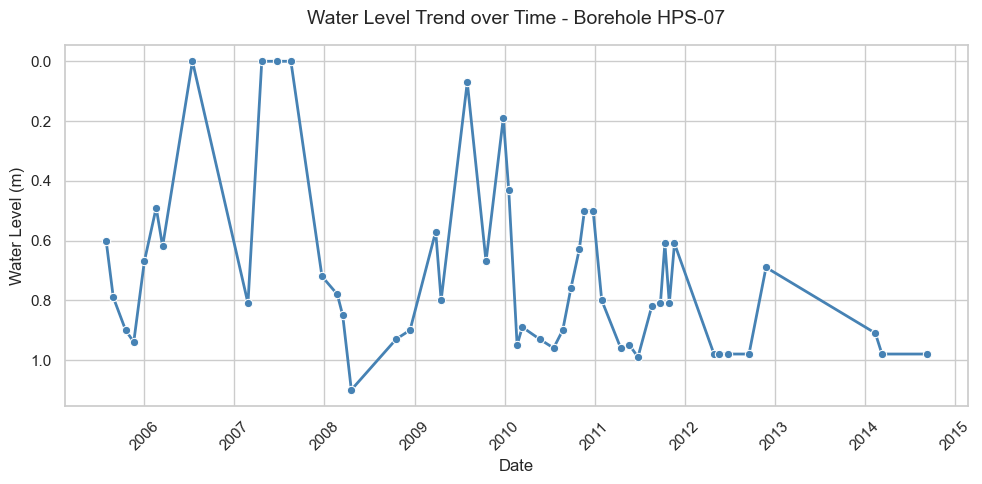

In [34]:
df_wells = pd.DataFrame(final_df)

# CHOOSE A WELL ID TO PLOT FROM THE AVAILABLE DATA
selected_well = 'HPS-07'

# EXECUTE THE VISUALIZATION FUNCTION
plot_borehole_water_level(df_wells, selected_well)